# Exercise: Create your own graph analyzer!

Create a set of functions to do some basic analysis of any undirected network. You can do as many measures as you want, but at least you should give the density, the degree distribution, the average degree and its variance, the average clustering coefficient and the diameter of the network. You cannot use for this exercise built-in functions that give back this quantities, except for the function `neighbors`.
Try it on at least thre different networks (sizes bigger than 1000 nodes). You can use any network data that you find either in [The colorado index of Complex Networks](https://icon.colorado.edu/#!/) or in [Netzschleuder](https://networks.skewed.de/).


In [1]:
# Import necessary packages
import networkx as nx, pandas as pd, numpy as np, matplotlib.pyplot as plt, itertools as it, collections
from queue import PriorityQueue
from tqdm import tqdm


# Some definitions that I will be using throughout the code

I do not know if can use functions like G.number_of_edges so I created them here

In [2]:
number_nodes = lambda G: len(list(G.nodes()))
degree = lambda G, node: len(list(nx.neighbors(G,node)))
degrees_graph = lambda G : np.array([degree(G, node) for node in G.nodes()])
number_edges = lambda G : len(list(G.edges())) 
number_edges_hsl = lambda G: np.sum(degrees_graph(G))//2 #alternatively, you can count the number of edges in a graph using the hand-shake lemma

# Density

The edge density of a network is defined as

$$\delta(G) = \frac{2m}{n(n-1)},$$

where $m$ is the number of edges on the graph and $n$ is the number of nodes.

In [3]:
def density(G):
    #the function counts the number of edges and nodes and returns the density
    m = number_edges(G)
    n = number_nodes(G)

    return 2*m/(n*(n-1))



# Degree distribution

Provides the probability that a randomly selected node in the network has degree $k$ :

$$p(k) = \frac{n_{k}}{n},$$

where $n_{k}$ is the number of nodes with degree $k$.

In [4]:
def degree_distribution(G):
    n = number_nodes(G)
    degrees = degrees_graph(G)
    n_k = np.array([np.count_nonzero(degrees == k) for k in range(0, np.max(degrees) + 1)]) # Count occurrences of each degree
    p = n_k/n
    
    #Now I plot a histogram.
    plt.bar(range(len(p)), p, width=0.8, color='b')
    plt.xlabel('Degree')
    plt.ylabel('Probability')
    plt.title('Degree Distribution')
    plt.show()
    return





# Average degree and its variance

Here it referes to the average degree of the graph and its variance:

$$ \langle k \rangle = \frac{1}{N} \sum^{N}_{i}k_{i} $$

$$ \sigma_{k} = \frac{1}{N} \sum_{i}^{N}\left( k_{i} - \langle k \rangle \right)  $$



In [5]:
def average_and_variance(G):
    average = np.mean(degrees_graph(G))
    variance = np.var(degrees_graph(G))
    std = np.std(degrees_graph(G))
    return average, variance, std



# Average and global Clustering

On one hand, we have the average WS clustering coefficient, which measures how locally clustered a network is on average. On the other hand, we have the transitivity index, which measures how globally clustered a network is.

$$ \bar{C} = \frac{1}{n} \sum_{i} C_{i} \, : \, C_{i} = \frac{2 t_{i}}{k_{i}(k_{i} -1)},$$

$$C = \frac{3|C_{3}|}{|P_{2}|} \, : \, \begin{cases}  |C_{3}| = \frac{1}{6} \text{tr}\left( A^{3} \right) \\  |P_{2}| = \frac{1}{2} \sum^{n}_{i=1}k_{i}(k_{i}-1) \end{cases}\, ,$$


where $\left|C_3\right|$ is the total number of triangles and $\left|P_2\right|$ the total number of paths of length two and $t_{i}$ denotes the number of transitive relations of the node $i$. Meanwhile, $t_i$ is the number of transitive relations of node $i$. Also, $A$ is the adjency matrix.

## Matrices
The **Adjacency, Degree**:
$$
A_{ij} := \begin{cases}1 & \text { if }(i, j) \in E \\ 0 & \text { if }(i, j) \notin E\end{cases}.
$$

In [6]:
#First we create a function to compute the adjency matrix

def Adjency_matrix(G):
    #We construct the adjency matrix with neighbours() method
    node_index = {node: i for i, node in enumerate(G.nodes())}

    # Initialize the adjacency matrix
    A = np.zeros((number_nodes(G),number_nodes(G)))

    # Fill the adjacency matrix
    for node in G.nodes():
        for neighbor in G.neighbors(node):
            A[node_index[node], node_index[neighbor]] = 1
        
    return A




In [7]:
#We now compute the transitivity index

def transitivity_index(G):
    C_3 = (1/6)*np.trace(np.linalg.matrix_power(Adjency_matrix(G), 3))
    P_2 = (1/2)*sum(degrees_graph(G)*(degrees_graph(G)-1))

    return 3*C_3/P_2




In [8]:
#We now compute the Watts Stroghatz Clustering Coefficient

def WS(G):
    def C_i(G, node):
        #Here we discard the nodes with less than two neighbors
        neighbors = list(G.neighbors(node))
        if len(neighbors) < 2:
            return 0.0

        num_edges = 0
        possible_edges = len(neighbors) * (len(neighbors) - 1) / 2  # Possible edges in the neighborhood

        #Here we create all the possible pairs looking at neighbors
        for u, v in it.combinations(neighbors, 2): # Number of transitive relations
            if G.has_edge(u, v)==True: #We check if there is and edge between the nodes u and v. If so, there is a triangle.
                num_edges += 1

        return num_edges / possible_edges

    C_is = np.array([C_i(G, node) for node in G.nodes()])
    return np.mean(C_is)






# Diameter of the network

The diameter o a graph is the largest distance between any pair of vertices, i.e. $max_{u,v}d(u,v)$. For this, there are different algorithms that can give us an approximate solution. In this case we will use the Dijkstra algorithm.

Dijkstra's Algorithm is used to fing the shortest path from one node to every other node and we will use that to measure the diameter.

In [9]:
def longest_path(G, start_node):
    
    N = len(G)  # Number of nodes in the graph

    # Initialize distances and visited status for all nodes
    for node in G.nodes:
        G.nodes[node]["distance"] = N  # Longest possible path is of length N-1, thus N is taken as the maximum distance (infinite)
        G.nodes[node]["visited"] = False  # Mark all nodes as unvisited

    # Set the distance of the starting node to 0
    G.nodes[start_node]["distance"] = 0

    # Initialize the priority queue and add the starting node with distance 0
    priority_queue = PriorityQueue()
    priority_queue.put((0, start_node))

    # Process the nodes in the priority queue
    while not priority_queue.empty():
        actual_node = priority_queue.get()[1]  # Get the node with the smallest distance

        # Iterate over all neighbors of the current node
        for neighbor in G.neighbors(actual_node):
            if not G.nodes[neighbor]["visited"]:  # If the neighbor has not been visited
                new_dist = G.nodes[actual_node]["distance"] + 1  # Calculate the new distance (unweighted graph)

                if new_dist < G.nodes[neighbor]["distance"]:  # If the new distance is shorter
                    G.nodes[neighbor]["distance"] = new_dist  # Update the distance
                    priority_queue.put((new_dist, neighbor))  # Add the neighbor to the priority queue

    # Return the distance of the farthest node from the start_node
    return max(G.nodes[node]["distance"] for node in G.nodes)

def diameter(G):
    diameter = 0
    for node in tqdm(list(G.nodes)): # I use the tqdm for predicting the time of output
        l = longest_path(G, node)
        if l > diameter:
            diameter = l
    return diameter





# Results

Here I will show the results

In [10]:
def results(G):
    dens = density(G)
    average, variance, std = average_and_variance(G)
    transitivity = transitivity_index(G)
    WS_coeff = WS(G)
    diam = diameter(G)

    #Here we show all the results 
    print(r"\langle k \rangle= ", average)
    print(r"\sigma^2= ", variance)
    print(r"\sigma= ", std)
    print(r"C= ", transitivity)
    print(r"C_{WS}= ", WS_coeff)
    print(r"D= ", diam)

    degree_distribution(G)
    return

In [11]:
def file_reader(filename):
    df = pd.read_csv(filename)
    return nx.from_pandas_edgelist(df, '# source', ' target')

# Western US Power Grid


100%|██████████| 4941/4941 [01:20<00:00, 61.63it/s]

\langle k \rangle=  2.66909532483303
\sigma^2=  3.208656315746206
\sigma=  1.7912722617587216
C=  0.10315322452860086
C_{WS}=  0.08010361108159712
D=  46


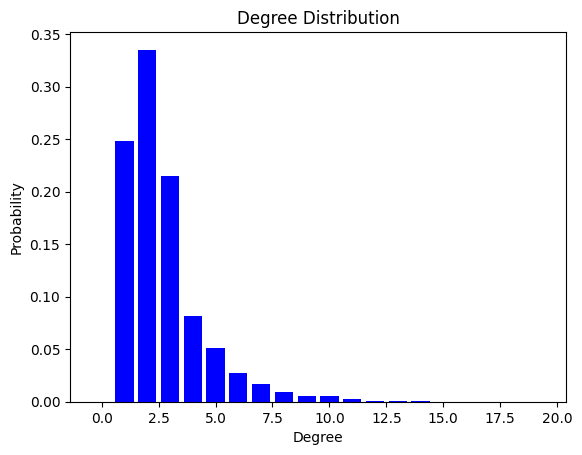

In [16]:
G = nx.read_edgelist(r"C:\Users\magic\OneDrive\Desktop\Programas\Python_programs\Complex_networks\Complex_networks_Master-main\power_grid_network\edges.csv", delimiter=",")

results(G)

# Euroroad network (2011)

100%|██████████| 1174/1174 [00:02<00:00, 407.89it/s]


\langle k \rangle=  2.41396933560477
\sigma^2=  1.4129564760613984
\sigma=  1.188678457809932
C=  0.0338863395693611
C_{WS}=  0.016731564857629593
D=  1174


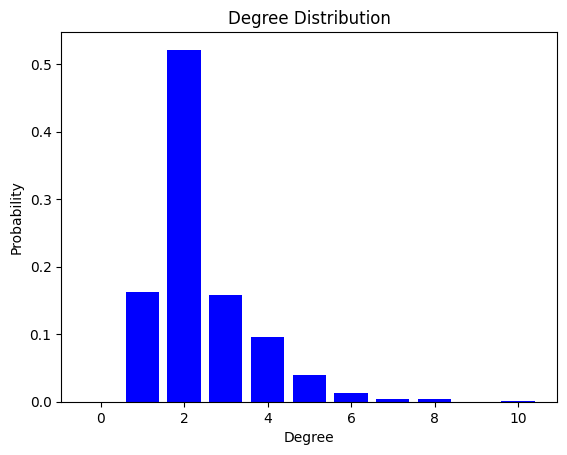

In [13]:
G = file_reader(r"C:\Users\magic\OneDrive\Desktop\Programas\Python_programs\Complex_networks\Complex_Networks_Master-main\network_euroroad\edges.csv")

results(G)

# Rosenfeld crime network (1991)


100%|██████████| 1380/1380 [00:03<00:00, 345.02it/s]

\langle k \rangle=  2.139130434782609
\sigma^2=  4.566149968494015
\sigma=  2.1368551585201123
C=  0.0
C_{WS}=  0.0
D=  1380


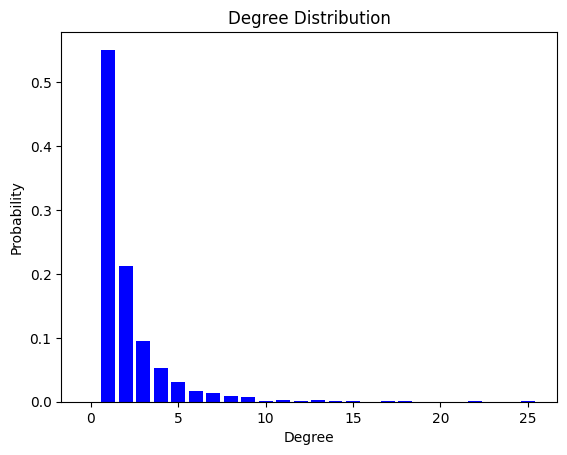

In [14]:
G = file_reader(r"C:\Users\magic\OneDrive\Desktop\Programas\Python_programs\Complex_networks\Complex_Networks_Master-main\network_rosenfeld\edges.csv")

results(G)